# Setup, render, and reference selection

This notebook is the entry point. Everything below this point assumes:

- PDF lives at `data/cd_set.pdf` (a 3-page plumbing CD set).
- Ground truth is generated by running a contour detector that filters
  for closed 6-vertex shapes in the expected size range. This is an
  approximation of GT, not a hand-marked benchmark. 
  The same GT is used by every strategy notebook so
  the comparison is apples-to-apples.

In [ ]:
import sys, os
from pathlib import Path
PKG_ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PKG_ROOT / 'src'))
os.chdir(PKG_ROOT)

import warnings
warnings.filterwarnings('ignore')

import numpy as np, cv2, matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 80

## 1. Render all pages + extract metadata

In [2]:
from symbol_matching import pdf_io, benchmark

PDF = benchmark.CD_SET_PDF
DPI = benchmark.DPI
print('PDF:', PDF)
print('Pages:', pdf_io.page_count(PDF))

metas = [pdf_io.extract_metadata(PDF, i) for i in range(pdf_io.page_count(PDF))]
for m in metas:
    print(f'  p{m.page_idx}  {m.sheet_ref:>6}  {m.page_type:>10}  {m.page_name}')

PDF: /home/ubuntu/Documents/symbol-matching/data/cd_set.pdf
Pages: 3
  p0    P120    Plumbing  PLUMBING SECOND FLOOR CONSTRUCTION PLAN
  p1    P121    Plumbing  PLUMBING SECOND FLOOR CONSTRUCTION PLAN ABOVE CEILING WASTE AND VENT PIPING
  p2    P130    Plumbing  KITCHEN EQUIPMENT PLUMBING CONNECTIONS SCHEDULE


## 2. Page previews

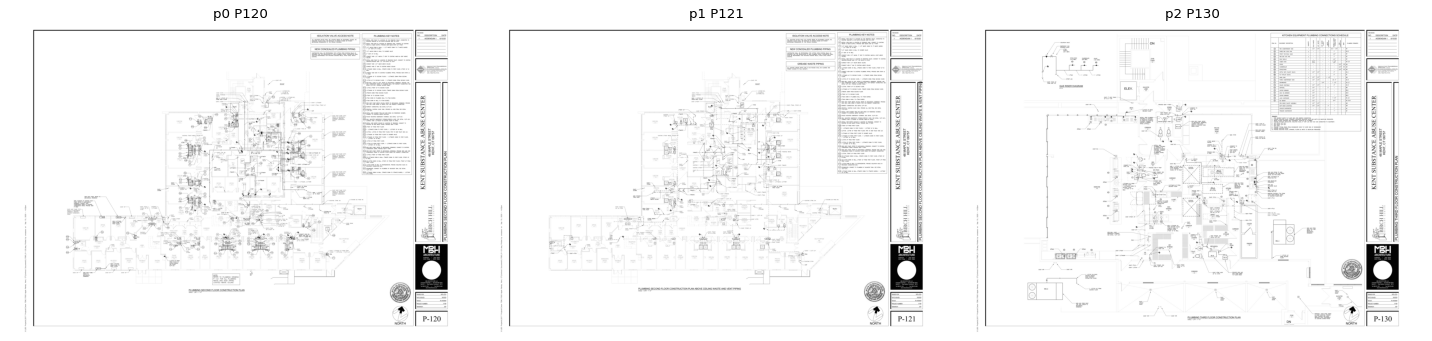

In [3]:
pages = [pdf_io.render_page(PDF, i, dpi=DPI) for i in range(len(metas))]
fig, axes = plt.subplots(1, len(pages), figsize=(18, 6))
for ax, im, m in zip(axes, pages, metas):
    # Downscale for display only.
    prev = cv2.resize(im, (im.shape[1]//5, im.shape[0]//5), interpolation=cv2.INTER_AREA)
    ax.imshow(prev, cmap='gray')
    ax.set_title(f'p{m.page_idx} {m.sheet_ref}')
    ax.axis('off')
plt.tight_layout(); plt.show()

## 3. The chosen reference symbol

reference shape: (66, 74)
reference bbox: BBox(x=7528, y=5424, w=74, h=66)


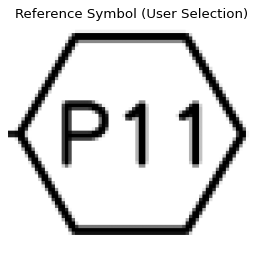

In [6]:
ref = benchmark.load_reference_crop()
print('reference shape:', ref.shape)
print('reference bbox:', benchmark.REFERENCE['bbox'])

plt.figure(figsize=(4, 4))
plt.imshow(cv2.resize(ref, (ref.shape[1]*4, ref.shape[0]*4), interpolation=cv2.INTER_NEAREST), cmap='gray')
plt.title('Reference Symbol (User Selection)')
plt.axis('off'); plt.show()

## 4. Ground-truth counts per page

In [7]:
gt = benchmark.ground_truth_per_page()
for pi, boxes in gt.items():
    print(f'  page {pi} ({metas[pi].sheet_ref}): {len(boxes)} GT callouts')

  page 0 (P120): 157 GT callouts
  page 1 (P121): 70 GT callouts
  page 2 (P130): 4 GT callouts


## 5. GT overlay on page 0

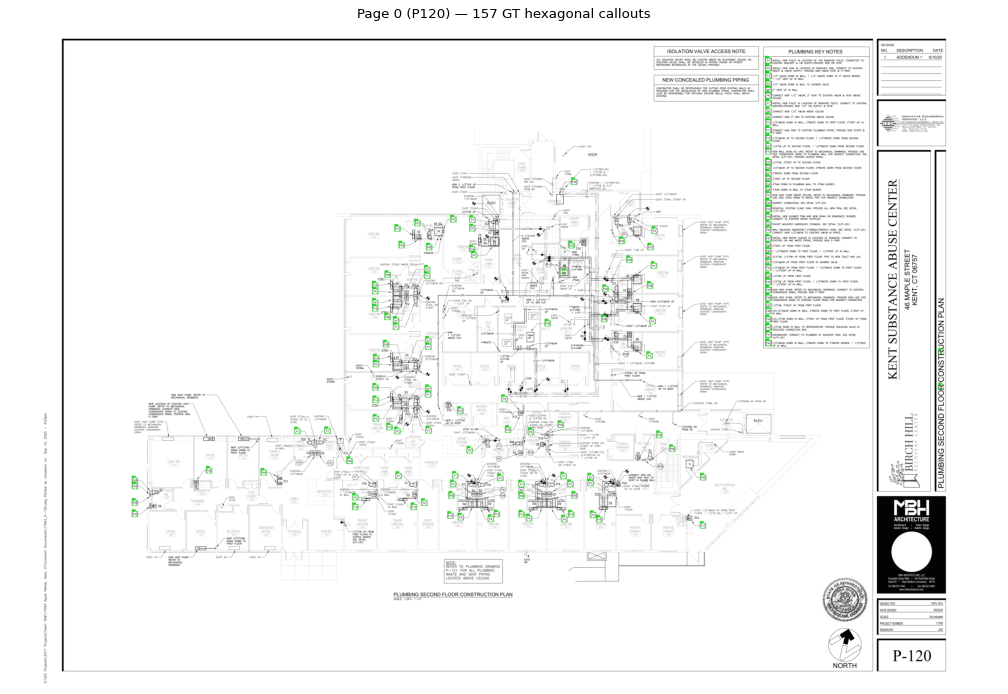

In [8]:
from symbol_matching import viz
from symbol_matching.records import BBox, Capture, DrawingItem, MatchResult, new_id

def gt_to_matches(page_idx, boxes):
    out = []
    for b in boxes:
        cap = Capture(
            id=new_id('cap'), source_page_id=metas[page_idx].sheet_ref or f'page-{page_idx}',
            page_idx=page_idx, page_name=metas[page_idx].page_name,
            sheet_ref=metas[page_idx].sheet_ref, page_type=metas[page_idx].page_type,
            bbox=b, rotation_deg=0, scale=1.0,
        )
        item = DrawingItem(id=new_id('item'), capture_id=cap.id, reference_id='GT', score=1.0, stage='template')
        out.append(MatchResult(capture=cap, item=item))
    return out

annotated = viz.annotate_page(pages[0], gt_to_matches(0, gt[0]), thickness=4, font_scale=0.5, color=(0, 200, 0))
prev = cv2.resize(annotated, (annotated.shape[1]//4, annotated.shape[0]//4), interpolation=cv2.INTER_AREA)
plt.figure(figsize=(16, 11))
plt.imshow(cv2.cvtColor(prev, cv2.COLOR_BGR2RGB))
plt.title(f'Page 0 ({metas[0].sheet_ref}) — {len(gt[0])} GT hexagonal callouts')
plt.axis('off'); plt.show()